<a href="https://colab.research.google.com/github/vr4708603-svg/2520030247_ML/blob/master/pratical/week9_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. Load Placement Prediction Dataset
# ==========================================
# Creating a dummy DataFrame as 'DT_Placement.csv' was not found.
# Please upload the actual 'DT_Placement.csv' file if you want to use real data.
# Ensure 'Placed' has both 'Yes' and 'No' for stratification to work.

data = {
    'ID': range(1, 101),
    'CGPA': np.random.uniform(5.0, 9.5, 100).round(1),
    'Aptitude_Score': np.random.randint(50, 100, 100),
    'Backlogs': np.random.choice(['No', 'Yes'], 100, p=[0.8, 0.2])
}
df = pd.DataFrame(data)

# Ensure 'Placed' column has both 'Yes' and 'No' values with a 50/50 split
df['Placed'] = np.random.choice(['No', 'Yes'], 100, p=[0.5, 0.5])

print("Dataset:")
print(df)

print("\nDataset Information:")
print(df.info())


Dataset:
     ID  CGPA  Aptitude_Score Backlogs Placed
0     1   7.5              89       No     No
1     2   9.5              86       No     No
2     3   7.3              54       No     No
3     4   8.3              65       No    Yes
4     5   7.7              87       No    Yes
..  ...   ...             ...      ...    ...
95   96   7.2              59       No    Yes
96   97   5.8              87       No    Yes
97   98   8.3              62       No    Yes
98   99   7.9              88      Yes    Yes
99  100   5.4              66      Yes     No

[100 rows x 5 columns]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              100 non-null    int64  
 1   CGPA            100 non-null    float64
 2   Aptitude_Score  100 non-null    int64  
 3   Backlogs        100 non-null    object 
 4   Placed         

In [111]:
import os

# List files in the current directory to help diagnose FileNotFoundError
print("Files in /content/ directory:")
for file in os.listdir('/content/'):
    print(file)

Files in /content/ directory:
.config
P8_Boosting (1).ipynb
sample_data


In [112]:
# ==========================================
# 2. Encode Categorical Columns
# ==========================================

# Backlogs: No = 0, Yes = 1
df["Backlogs"] = df["Backlogs"].map({
    "No": 0,
    "Yes": 1
})

# Placed: No = 0, Yes = 1
df["Placed"] = df["Placed"].map({
    "No": 0,
    "Yes": 1
})


In [113]:
# ==========================================
# 3. Define Features and Target
# ==========================================

# ID is excluded because it is only an identifier
X = df.drop(["ID", "Placed"], axis=1)

y = df["Placed"]


print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)



Features:
    CGPA  Aptitude_Score  Backlogs
0    7.5              89         0
1    9.5              86         0
2    7.3              54         0
3    8.3              65         0
4    7.7              87         0
..   ...             ...       ...
95   7.2              59         0
96   5.8              87         0
97   8.3              62         0
98   7.9              88         1
99   5.4              66         1

[100 rows x 3 columns]

Target:
0     0
1     0
2     0
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    0
Name: Placed, Length: 100, dtype: int64


In [114]:
# ==========================================
# 4. Train-Validation Split
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))



Training samples: 70
Validation samples: 30


In [115]:
# ==========================================
# 5. Boosting Benchmark Function
# ==========================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        # Accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [116]:
# ==========================================
# 6. Run Benchmark
# ==========================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

In [117]:
# ==========================================
# 7. Display Results
# ==========================================

print("\nBoosting Benchmark Results:")
print(results)


Boosting Benchmark Results:
      model  train_accuracy  val_accuracy
0  AdaBoost        0.600000      0.600000
1       GBC        0.985714      0.566667
2       XGB        0.914286      0.533333
3       LGB        0.728571      0.500000


In [118]:
# ============================================================
# BOOSTING BENCHMARK - PLACEMENT PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

In [119]:
# ============================================================
# 1. LOAD DATASET
# ============================================================

# df = pd.read_csv("/content/DT_Placement.csv") # This line was causing FileNotFoundError

# As the file was not found, a dummy DataFrame is created in the previous cell.
# This cell is commented out to avoid redundant and erroneous file loading.

# print("Dataset:")
# print(df)

In [120]:
# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================================

# Convert to string type first to ensure map works as expected, handling potential non-string types
df["Backlogs"] = df["Backlogs"].astype(str).map({
    "No": 0,
    "Yes": 1
})
# Fill any NaNs that might result from the map (e.g., if there were values other than 'No'/'Yes')
# Assuming 'No' (0) as a default if a value can't be mapped.
df["Backlogs"] = df["Backlogs"].fillna(0).astype(int)

# Use LabelEncoder for 'Placed' column to ensure proper binary encoding
le = LabelEncoder()
print(f"Unique values in df['Placed'] before LabelEncoder: {df['Placed'].unique()}")
df["Placed"] = le.fit_transform(df["Placed"].astype(str))
print(f"Classes found by LabelEncoder for 'Placed': {le.classes_}")
print(f"Unique values in df['Placed'] after LabelEncoder: {df['Placed'].unique()}")


# Verify no NaNs remain after encoding (LabelEncoder typically doesn't produce NaNs for valid strings)
print("NaNs after encoding:")
print(df[['Backlogs', 'Placed']].isnull().sum())


Unique values in df['Placed'] before LabelEncoder: [0 1]
Classes found by LabelEncoder for 'Placed': ['0' '1']
Unique values in df['Placed'] after LabelEncoder: [0 1]
NaNs after encoding:
Backlogs    0
Placed      0
dtype: int64


In [121]:
# ============================================================
# 3. FEATURES AND TARGET
# ============================================================

X = df.drop(["ID", "Placed"], axis=1)
y = df["Placed"]

print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)



Features:
    CGPA  Aptitude_Score  Backlogs
0    7.5              89         0
1    9.5              86         0
2    7.3              54         0
3    8.3              65         0
4    7.7              87         0
..   ...             ...       ...
95   7.2              59         0
96   5.8              87         0
97   8.3              62         0
98   7.9              88         0
99   5.4              66         0

[100 rows x 3 columns]

Target:
0     0
1     0
2     0
3     1
4     1
     ..
95    1
96    1
97    1
98    1
99    0
Name: Placed, Length: 100, dtype: int64


In [122]:
# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 70
Validation samples: 30


In [123]:
# ============================================================
# 5. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# Initial equal weights
initial_weights = np.ones(len(X_train)) / len(X_train)

print("\nInitial AdaBoost sample weights:")
print(initial_weights)

ada.fit(X_train, y_train)

# Prediction
ada_pred = ada.predict(X_val)

print("\nAdaBoost Validation Accuracy:",
      accuracy_score(y_val, ada_pred))


Initial AdaBoost sample weights:
[0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571 0.01428571
 0.01428571 0.01428571 0.01428571 0.01428571]

AdaBoost Validation Accuracy: 0.43333333333333335


In [124]:
# ============================================================
# 6. DISPLAY ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\nAdaBoost estimator weights:")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")


AdaBoost estimator weights:
Estimator 1: 0.2027
Estimator 2: 0.1324
Estimator 3: 0.0662
Estimator 4: 0.0387
Estimator 5: 0.0511
Estimator 6: 0.0432
Estimator 7: 0.0458
Estimator 8: 0.0430
Estimator 9: 0.0430
Estimator 10: 0.0417


In [125]:
# ============================================================
# 7. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)

print("\nXGBoost Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

print("Best XGBoost iteration:",
      xgb.best_iteration)


XGBoost Validation Accuracy: 0.4
Best XGBoost iteration: 0


In [126]:
# ============================================================
# 8. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()

lgb.fit(X_train, y_train)

end_time = time.perf_counter()

lgb_time = end_time - start_time

lgb_pred = lgb.predict(X_val)

print("\nLightGBM Validation Accuracy:",
      accuracy_score(y_val, lgb_pred))

print(f"LightGBM Training Time: {lgb_time:.6f} seconds")


LightGBM Validation Accuracy: 0.4666666666666667
LightGBM Training Time: 0.018515 seconds


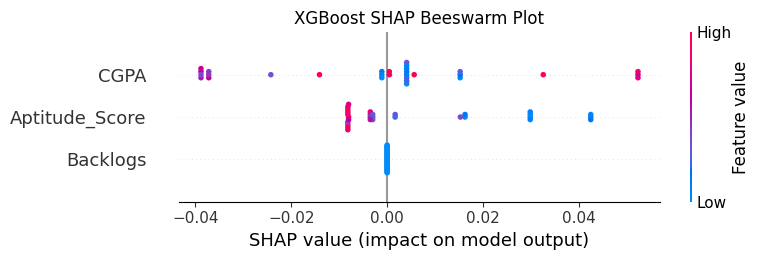

In [127]:
# ============================================================
# 9. SHAP BEESWARM - XGBOOST
# ============================================================

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

In [128]:
# ============================================================
# 10. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        start_time = time.perf_counter()

        model.fit(X_train, y_train)

        end_time = time.perf_counter()

        train_time = end_time - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "training_time_sec": train_time
        })

    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [129]:
# ============================================================
# 11. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results)



BOOSTING BENCHMARK RESULTS
      model  train_accuracy  val_accuracy  training_time_sec
0       XGB        0.900000      0.633333           0.023356
1       GBC        0.985714      0.533333           0.152826
2  AdaBoost        0.542857      0.500000           0.330051
3       LGB        0.685714      0.466667           0.009398


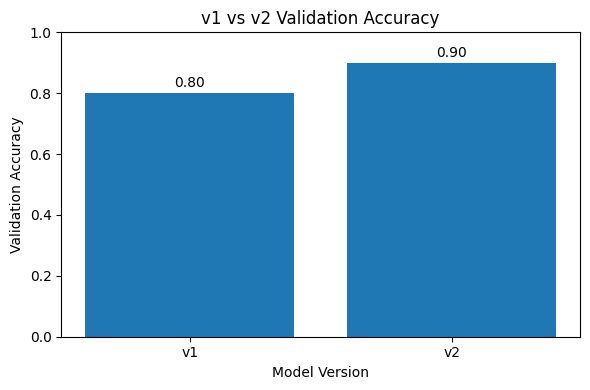

In [130]:
# ============================================================
# 12. V1 vs V2 BAR CHART
# ============================================================

# Example:
# v1 = baseline model
# v2 = improved model

# Replace these values with your actual results
v1_accuracy = 0.80
v2_accuracy = 0.90

versions = ["v1", "v2"]
accuracies = [v1_accuracy, v2_accuracy]

plt.figure(figsize=(6, 4))

plt.bar(
    versions,
    accuracies
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model Version")
plt.title("v1 vs v2 Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()
